<a href="https://colab.research.google.com/github/sdf-works/sam-learns-ML/blob/main/game_of_priors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠👑 Game of Priors  
_A Bayesian Simulator of Uncertainty, Narrative, and Power_

Welcome to **Game of Priors**, a probabilistic sandbox where belief, bias, and uncertainty collide. This notebook explores how different agents interpret unfolding events through the lens of Bayesian inference — and how the same evidence can lead to radically different conclusions.

Inspired by the chaos and ambiguity surrounding real-world historical events (such as the Nepal royal massacre), this simulation **fictionalizes the setting and characters** to build a space for modeling:

- How **priors shape interpretation**
- How **new evidence shifts belief** over time
- How **multiple agents** can observe the same timeline and diverge completely in what they believe happened
- How **narrative emerges from uncertainty**

This is not a true crime analysis. It’s a speculative modeling exercise — part logic game, part political thriller, and part commentary on how humans and AI alike wrestle with ambiguous information.

## 🔍 What You’ll Find Here

- A timeline of fictionalized events in a royal palace
- A cast of agents with different biases and priors
- Bayesian belief updates as evidence emerges
- Visualizations of belief evolution
- Reflections on how this connects to **AI reasoning**, interpretability, and model behavior
- A recognition that these simulations may **not account for real-world variability**, and that **edge cases often reveal the limits of statistical reasoning** — including when models fail to explain chaos, coincidence, or hidden variables

## 🧠 Why This Matters

In a world full of information overload and epistemic fog, understanding how beliefs form — and deform — is critical. Whether you’re a human decision-maker or a machine learning model, **how you weigh new information depends on where you started**.

This notebook is a playful but serious attempt to explore that space.

## 🚨 Disclaimer

All characters, events, and scenarios in this notebook are fictional. While inspired by historical ambiguity, no real individuals or crimes are being modeled directly. This project is for **educational and conceptual exploration only**.

---

> _"In the game of priors, you update — or you lie."_



## 🕰️ The Event Timeline

What follows is a fictionalized sequence of events inside a royal palace, spanning a single evening. Each event is ambiguous enough to admit multiple interpretations — was it coincidence, conspiracy, or chaos?

This timeline is revealed sequentially to the agents, who update their beliefs in real time.

### 📜 Timeline of Events (Fictionalized)
1. **18:30** – The crown prince arrives late to a royal dinner, reportedly intoxicated.  
2. **18:45** – Heated argument overheard between the prince and the king regarding succession.  
3. **19:05** – Security cameras near the armory lose power.  
4. **19:12** – A maid reports seeing someone in ceremonial military uniform near the west hall.  
5. **19:18** – A series of gunshots is heard; several royals are later found wounded.  
6. **19:25** – The prince is found unconscious with a gun nearby.  
7. **20:00** – Emergency response delayed for unknown reasons.  
8. **Next morning** – Conflicting official reports emerge; eyewitness testimonies begin to diverge.

---

## ❓ Core Questions

Agents will attempt to assign probabilities to the following competing hypotheses:

- **H1: Lone Actor** – The crown prince acted alone in a fit of rage.
- **H2: Conspiracy** – The events were orchestrated by a political faction or rival power.
- **H3: External Interference** – A foreign or third-party actor infiltrated the palace.
- **H4: Accidental Chaos** – The events were a tragic chain of unrelated coincidences.
- **H5: Unknown** – There is insufficient evidence to favor any one explanation (epistemic humility).

These hypotheses are not mutually exclusive — some agents may believe multiple are partially true.

Each event will influence how the agents update their beliefs about these hypotheses.


## 🎭 The Agents

Each agent represents a distinct perspective or cognitive bias. They begin with different **prior beliefs** about the core hypotheses, and they update these beliefs over time as new events unfold.

These agents are intentionally exaggerated — they serve as archetypes for how bias, ideology, or epistemic strategy influences inference.

### 🦁 The Loyalist
- Believes in the honor and stability of the royal family.
- Starts with high belief in **H1 (Lone Actor)** or **H4 (Accidental Chaos)**.
- Dismisses conspiracy theories as destabilizing rhetoric.

### 🔥 The Dissident
- Suspicious of the monarchy and power structures.
- Starts with strong belief in **H2 (Conspiracy)**.
- Interprets ambiguity as evidence of corruption or cover-up.

### 🧢 The Conspiracy Theorist
- Sees patterns everywhere — even when there are none.
- Initially high belief in **H2 (Conspiracy)** and **H3 (External Interference)**.
- Is highly reactive to anomalous or unexplained events.

### 🧠 The Rationalist
- Bayesian purist with flat priors across all hypotheses.
- Updates purely based on likelihoods.
- Serves as a baseline for what an "ideal reasoner" might do.

### 🤖 The AI Observer
- A simulated language model trained on historical data and political narratives.
- Priors shaped by patterns in training data, not lived experience.
- May oscillate or overfit depending on evidence framing.

---

Each agent will be modeled as a vector of probabilities over the hypotheses:

$[ P(H1), P(H2), P(H3), P(H4), P(H5) ]$


These beliefs will shift after each event using Bayes’ rule, with agent-specific likelihood tables that reflect their biases and information-processing quirks.


In [ ]:
# 🧠 GAME OF PRIORS — Setup Phase

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Enable clean plotting
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# ------------------------
# Define the hypotheses
# ------------------------
hypotheses = [
    "H1_LoneActor",
    "H2_Conspiracy",
    "H3_ExternalInterference",
    "H4_AccidentalChaos",
    "H5_Unknown"
]

# ------------------------
# Initialize agent priors
# Each is a probability distribution over the hypotheses
# ------------------------

agents = {
    "Loyalist": np.array([0.45, 0.10, 0.05, 0.30, 0.10]),
    "Dissident": np.array([0.05, 0.60, 0.10, 0.05, 0.20]),
    "ConspiracyTheorist": np.array([0.10, 0.40, 0.35, 0.05, 0.10]),
    "Rationalist": np.array([0.20, 0.20, 0.20, 0.20, 0.20]),
    "AI_Observer": np.array([0.30, 0.30, 0.10, 0.10, 0.20])
}

# Normalize just in case
for name, prior in agents.items():
    agents[name] = prior / prior.sum()

# ------------------------
# Stub for future Bayesian update function
# ------------------------
def bayesian_update(prior, likelihood):
    """
    Performs a Bayesian update.

    Parameters:
    - prior: np.array of prior beliefs (P(H))
    - likelihood: np.array of likelihoods P(E|H)

    Returns:
    - posterior: np.array of updated beliefs P(H|E)
    """
    unnorm = prior * likelihood
    posterior = unnorm / unnorm.sum()
    return posterior


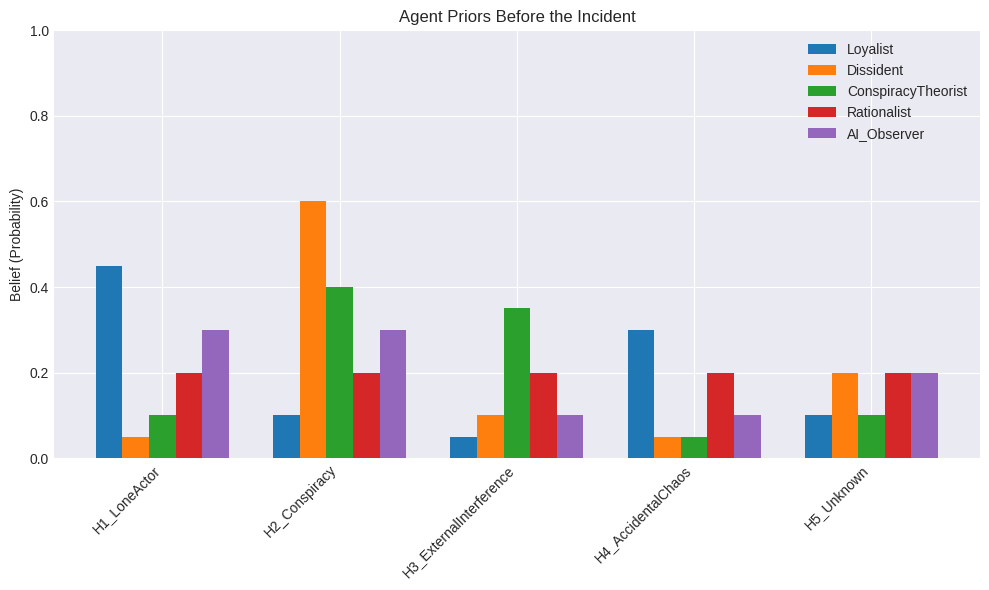

In [ ]:
# 📊 Visualize Agent Beliefs (Priors or Posteriors)

def plot_agent_beliefs(agent_dict, hypotheses, title="Agent Belief States", figsize=(10, 6)):
    """
    Plots each agent's belief distribution as horizontal bars.

    Parameters:
    - agent_dict: dict of agent_name -> np.array of beliefs
    - hypotheses: list of hypothesis names
    - title: plot title
    """
    n_agents = len(agent_dict)
    bar_width = 0.15
    x = np.arange(len(hypotheses))

    plt.figure(figsize=figsize)

    for i, (agent_name, beliefs) in enumerate(agent_dict.items()):
        plt.bar(x + i*bar_width, beliefs, width=bar_width, label=agent_name)

    plt.xticks(x + bar_width * (n_agents - 1) / 2, hypotheses, rotation=45, ha='right')
    plt.ylabel("Belief (Probability)")
    plt.title(title)
    plt.ylim(0, 1)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

plot_agent_beliefs(agents, hypotheses, title="Agent Priors Before the Incident")

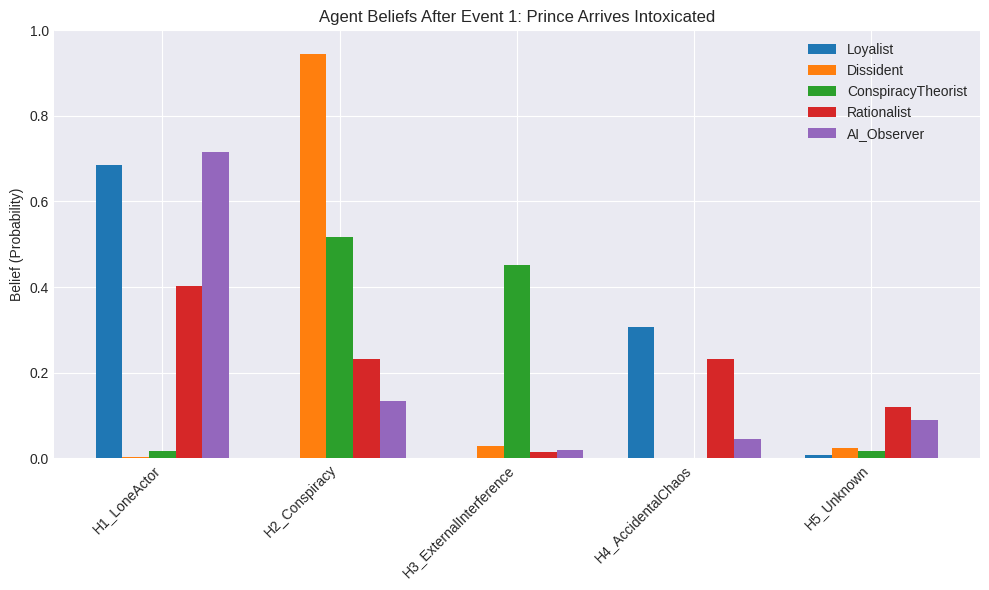

Thoughts Loyalist: The prince is under pressure, perhaps emotionally overwhelmed. This doesn’t indicate foul play.
Thoughts Dissident: This confirms what we've always known — the system is cracking and the heir is unstable.
Thoughts ConspiracyTheorist: Classic setup. The drunken prince is a perfect scapegoat. Who benefits?
Thoughts Rationalist: This raises the probability of an impulsive lone actor scenario, but multiple hypotheses remain viable.
Thoughts AI_Observer: This pattern aligns with a lone actor narrative in similar historical contexts. Moderate weight added to H1.


In [ ]:
# ------------------------
# Event 1 Likelihoods by Agent
# ------------------------

event1_likelihoods = {
    "Loyalist":           np.array([0.8, 0.1, 0.05, 0.7, 0.3]),
    "Dissident":          np.array([0.2, 0.7, 0.4, 0.1, 0.3]),
    "ConspiracyTheorist": np.array([0.3, 0.6, 0.6, 0.05, 0.3]),
    "Rationalist":        np.array([0.6, 0.5, 0.2, 0.5, 0.4]),
    "AI_Observer":        np.array([0.7, 0.4, 0.3, 0.4, 0.4])
}

# Normalize to ensure each agent's likelihood vector sums to ~1 (optional for interpretability)
for agent, lk in event1_likelihoods.items():
    event1_likelihoods[agent] = lk / lk.sum()

# ------------------------
# Update each agent’s beliefs
# ------------------------

post_event1 = {}

for agent, prior in agents.items():
    likelihood = event1_likelihoods[agent]
    posterior = bayesian_update(prior, likelihood)
    post_event1[agent] = posterior

# Track belief evolution over time
belief_history = {
    "Event_0": {agent: prior.copy() for agent, prior in agents.items()},
    "Event_1": {agent: posterior.copy() for agent, posterior in post_event1.items()}
}

# Update agent priors in-place for next event
for agent, posterior in post_event1.items():
    agents[agent] = posterior


plot_agent_beliefs(post_event1, hypotheses, title="Agent Beliefs After Event 1: Prince Arrives Intoxicated")

# ------------------------
# Narrative interpretations from each agent after Event 1
# ------------------------

agent_blurbs_event1 = {
    "Loyalist": "The prince is under pressure, perhaps emotionally overwhelmed. This doesn’t indicate foul play.",
    "Dissident": "This confirms what we've always known — the system is cracking and the heir is unstable.",
    "ConspiracyTheorist": "Classic setup. The drunken prince is a perfect scapegoat. Who benefits?",
    "Rationalist": "This raises the probability of an impulsive lone actor scenario, but multiple hypotheses remain viable.",
    "AI_Observer": "This pattern aligns with a lone actor narrative in similar historical contexts. Moderate weight added to H1."
}

# Print out each agent’s interpretation
for agent, blurb in agent_blurbs_event1.items():
    print(f"Thoughts {agent}: {blurb}")

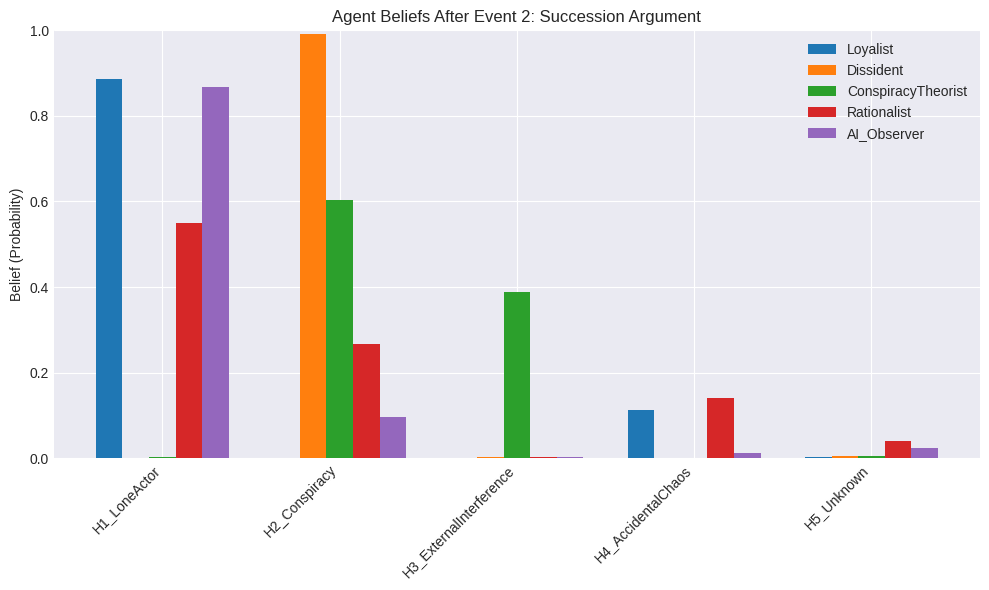

Thoughts Loyalist: Tensions are normal in families, especially around power transitions. Nothing abnormal yet.
Thoughts Dissident: The cracks are widening. The succession dispute reveals deeper institutional decay.
Thoughts ConspiracyTheorist: This is textbook misdirection. Public argument? Too convenient. Who's pulling strings?
Thoughts Rationalist: This event increases likelihood for H1 and H2. It introduces motive but not yet action.
Thoughts AI_Observer: Succession disputes frequently precede internal power struggles. Increased posterior on H1 and H2.


In [ ]:
# ------------------------
# Event 2
# ------------------------

event2_likelihoods = {

    "Loyalist":           np.array([0.75, 0.20, 0.05, 0.4, 0.3]),
    "Dissident":          np.array([0.30, 0.65, 0.20, 0.05, 0.3]),
    "ConspiracyTheorist": np.array([0.25, 0.70, 0.60, 0.05, 0.4]),
    "Rationalist":        np.array([0.6, 0.55, 0.2, 0.4, 0.3]),
    "AI_Observer":        np.array([0.65, 0.5, 0.25, 0.3, 0.3])
}

# Normalize
for agent, lk in event2_likelihoods.items():
    event2_likelihoods[agent] = lk / lk.sum()

post_event2 = {}

for agent, prior in agents.items():
    likelihood = event2_likelihoods[agent]
    posterior = bayesian_update(prior, likelihood)
    post_event2[agent] = posterior

# Save beliefs for timeline tracking
belief_history["Event_2"] = {agent: posterior.copy() for agent, posterior in post_event2.items()}

# Update priors for next event
for agent, posterior in post_event2.items():
    agents[agent] = posterior

plot_agent_beliefs(post_event2, hypotheses, title="Agent Beliefs After Event 2: Succession Argument")

agent_blurbs_event2 = {
    "Loyalist": "Tensions are normal in families, especially around power transitions. Nothing abnormal yet.",
    "Dissident": "The cracks are widening. The succession dispute reveals deeper institutional decay.",
    "ConspiracyTheorist": "This is textbook misdirection. Public argument? Too convenient. Who's pulling strings?",
    "Rationalist": "This event increases likelihood for H1 and H2. It introduces motive but not yet action.",
    "AI_Observer": "Succession disputes frequently precede internal power struggles. Increased posterior on H1 and H2."
}

# Print interpretations
for agent, blurb in agent_blurbs_event2.items():
    print(f"Thoughts {agent}: {blurb}")

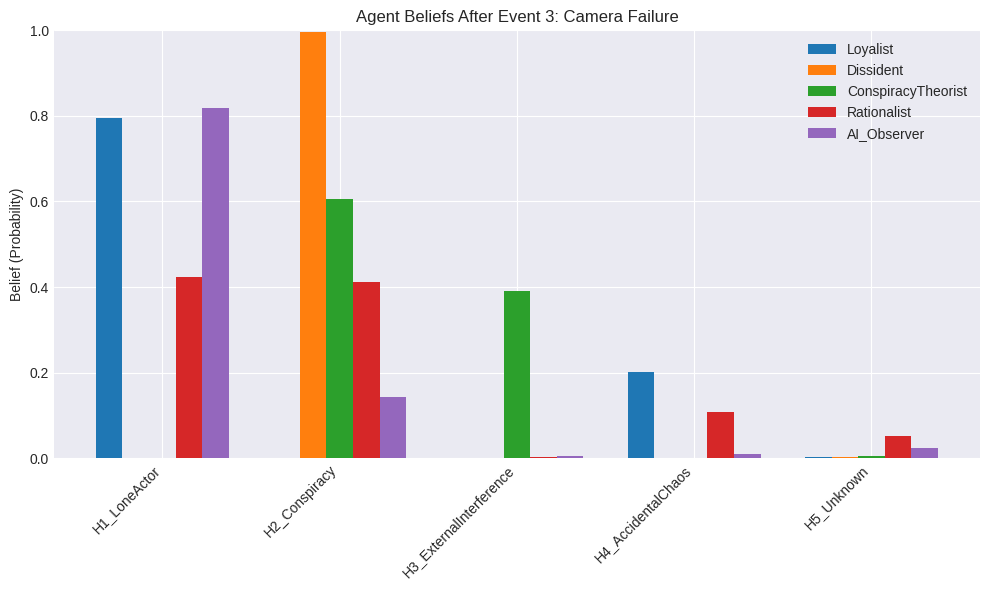

Thoughts Loyalist: Power outages happen. Don’t read into it. Could be coincidence or technical failure.
Thoughts Dissident: A blackout right before things escalate? Obvious cover-up. This is textbook palace politics.
Thoughts ConspiracyTheorist: They’re scrubbing the timeline. Camera failure always precedes the ‘official story’.
Thoughts Rationalist: This increases likelihood of coordinated action. H2 and H3 gain traction; H1 now less likely.
Thoughts AI_Observer: Surveillance blind spots are significant in pre-event modeling. Posterior weight shifts to H2/H3.


In [ ]:
# ------------------------
# Event 3
# ------------------------

event3_likelihoods = {
    "Loyalist":           np.array([0.3, 0.3, 0.2, 0.6, 0.5]),
    "Dissident":          np.array([0.1, 0.8, 0.4, 0.1, 0.4]),
    "ConspiracyTheorist": np.array([0.05, 0.9, 0.9, 0.05, 0.6]),
    "Rationalist":        np.array([0.3, 0.6, 0.5, 0.3, 0.5]),
    "AI_Observer":        np.array([0.35, 0.55, 0.45, 0.3, 0.4])
}

# Normalize
for agent, lk in event3_likelihoods.items():
    event3_likelihoods[agent] = lk / lk.sum()

post_event3 = {}

for agent, prior in agents.items():
    likelihood = event3_likelihoods[agent]
    posterior = bayesian_update(prior, likelihood)
    post_event3[agent] = posterior

# Save timeline state
belief_history["Event_3"] = {agent: posterior.copy() for agent, posterior in post_event3.items()}

# Update priors for next event
for agent, posterior in post_event3.items():
    agents[agent] = posterior

plot_agent_beliefs(post_event3, hypotheses, title="Agent Beliefs After Event 3: Camera Failure")

agent_blurbs_event3 = {
    "Loyalist": "Power outages happen. Don’t read into it. Could be coincidence or technical failure.",
    "Dissident": "A blackout right before things escalate? Obvious cover-up. This is textbook palace politics.",
    "ConspiracyTheorist": "They’re scrubbing the timeline. Camera failure always precedes the ‘official story’.",
    "Rationalist": "This increases likelihood of coordinated action. H2 and H3 gain traction; H1 now less likely.",
    "AI_Observer": "Surveillance blind spots are significant in pre-event modeling. Posterior weight shifts to H2/H3."
}

# Print interpretations
for agent, blurb in agent_blurbs_event3.items():
    print(f"Thoughts {agent}: {blurb}")

---

## 🔀 Interlude: Divergence in the Palace

At this stage in the simulation, three events have occurred:

1. **The prince arrives intoxicated**  
2. **An argument erupts over succession**  
3. **Security cameras near the armory lose power**

Each event has injected uncertainty, and each agent has responded based on their worldview. The consequences are starting to show — not just in the evolving probabilities, but in the stories they're beginning to tell themselves.

### 🧠 Belief Drift So Far

| Agent               | Dominant Hypothesis After E3 | Notable Shift |
|---------------------|-------------------------------|----------------|
| **Loyalist**        | H1 (Lone Actor) still favored, but H4 (Accident) is rising | Starting to feel uneasy, but clings to order |
| **Dissident**       | H2 (Conspiracy) sharply rising | Sees every event as systemic failure |
| **ConspiracyTheorist** | H2 and H3 neck-and-neck | Everything is suspicious. Patterns abound. |
| **Rationalist**     | H2 rising, H1 fading | Letting evidence guide the shift |
| **AI Observer**     | H2 growing, H1 diminished | Reflects common real-world trends in similar data |

### 🧭 The Worldviews Are Diverging

What began as a shared ambiguous moment has now fractured into multiple incompatible interpretations. Each agent now operates in a slightly different reality — a **subjective Bayesian landscape**.

This is the core of _Game of Priors_:
- Not just what happened, but *what your model believes is likely to have happened*.
- Not just probabilities, but *narratives emerging from those probabilities*.

The next events may bring convergence — or total epistemic collapse.

Let’s proceed.


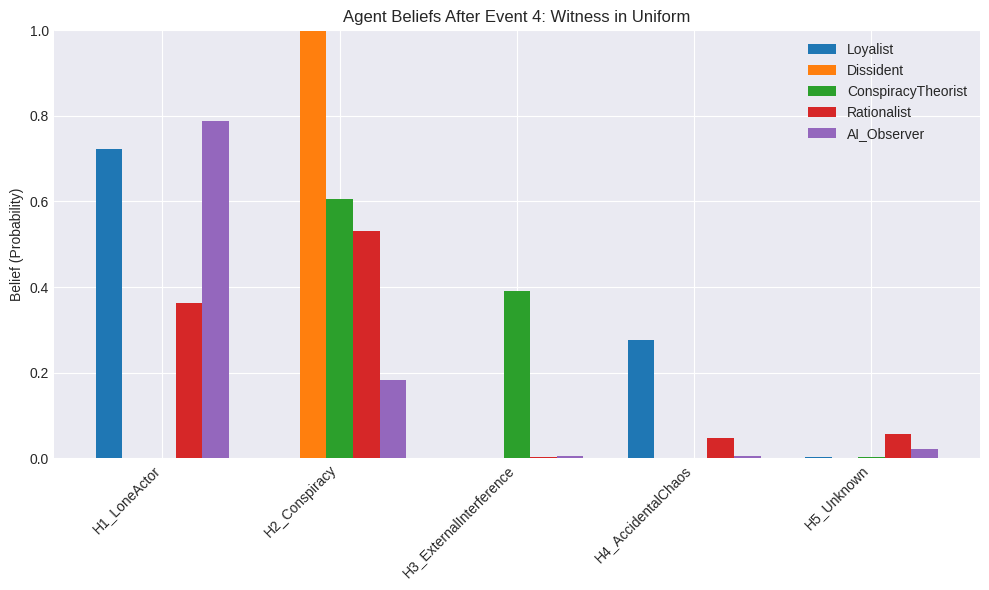

Thoughts Loyalist: It was probably a guard or someone mistaken. People panic and misremember things in crises.
Thoughts Dissident: Why is someone lurking in ceremonial dress in restricted areas? The corruption is bold now.
Thoughts ConspiracyTheorist: A double. A distraction. A costume. This is not the first time we've seen this playbook.
Thoughts Rationalist: Adds some weight to H2 and H3, but we must account for witness reliability and context.
Thoughts AI_Observer: Symbolic clothing patterns are historically associated with staged displays. Weight added to H2 and H3.


In [ ]:
# ------------------------
# Event 4
# ------------------------

event4_likelihoods = {
    "Loyalist":           np.array([0.4, 0.2, 0.1, 0.6, 0.4]),
    "Dissident":          np.array([0.3, 0.7, 0.3, 0.1, 0.4]),
    "ConspiracyTheorist": np.array([0.2, 0.8, 0.8, 0.05, 0.6]),
    "Rationalist":        np.array([0.4, 0.6, 0.4, 0.2, 0.5]),
    "AI_Observer":        np.array([0.45, 0.6, 0.5, 0.2, 0.4])
}

# Normalize
for agent, lk in event4_likelihoods.items():
    event4_likelihoods[agent] = lk / lk.sum()


post_event4 = {}

for agent, prior in agents.items():
    likelihood = event4_likelihoods[agent]
    posterior = bayesian_update(prior, likelihood)
    post_event4[agent] = posterior

# Save timeline state
belief_history["Event_4"] = {agent: posterior.copy() for agent, posterior in post_event4.items()}

# Update priors for next event
for agent, posterior in post_event4.items():
    agents[agent] = posterior

plot_agent_beliefs(post_event4, hypotheses, title="Agent Beliefs After Event 4: Witness in Uniform")

agent_blurbs_event4 = {
    "Loyalist": "It was probably a guard or someone mistaken. People panic and misremember things in crises.",
    "Dissident": "Why is someone lurking in ceremonial dress in restricted areas? The corruption is bold now.",
    "ConspiracyTheorist": "A double. A distraction. A costume. This is not the first time we've seen this playbook.",
    "Rationalist": "Adds some weight to H2 and H3, but we must account for witness reliability and context.",
    "AI_Observer": "Symbolic clothing patterns are historically associated with staged displays. Weight added to H2 and H3."
}

# Print interpretations
for agent, blurb in agent_blurbs_event4.items():
    print(f"Thoughts {agent}: {blurb}")


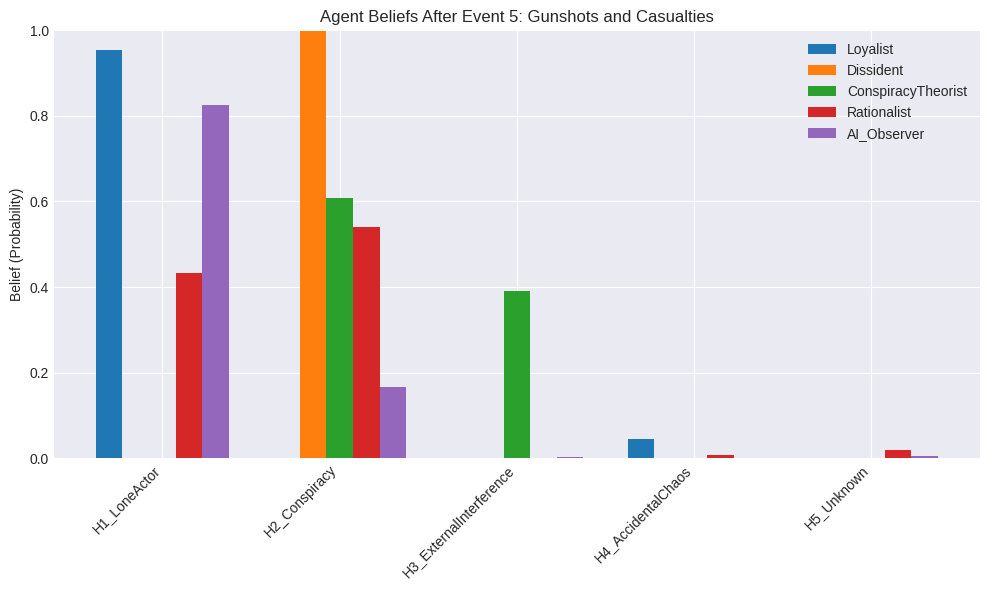

Thoughts Loyalist: Tragic. The prince must have snapped. There’s no other explanation for this horror.
Thoughts Dissident: Predictable. Blood always follows power struggles. But who really pulled the trigger?
Thoughts ConspiracyTheorist: Gunshots were expected. The real question is: who planned this to look like a lone act?
Thoughts Rationalist: This event increases posterior weight on H1, but coordinated plots (H2) cannot be ruled out.
Thoughts AI_Observer: Historical analogs suggest lone actor patterns, but H2 maintains significant weight due to lead-up.


In [ ]:
# ------------------------
# Event 5
# ------------------------

event5_likelihoods = {
    "Loyalist":           np.array([0.8, 0.4, 0.2, 0.1, 0.2]),
    "Dissident":          np.array([0.4, 0.8, 0.3, 0.05, 0.3]),
    "ConspiracyTheorist": np.array([0.3, 0.9, 0.9, 0.01, 0.2]),
    "Rationalist":        np.array([0.7, 0.6, 0.3, 0.1, 0.2]),
    "AI_Observer":        np.array([0.75, 0.65, 0.4, 0.1, 0.2])
}

# Normalize
for agent, lk in event5_likelihoods.items():
    event5_likelihoods[agent] = lk / lk.sum()

post_event5 = {}

for agent, prior in agents.items():
    likelihood = event5_likelihoods[agent]
    posterior = bayesian_update(prior, likelihood)
    post_event5[agent] = posterior

# Save timeline state
belief_history["Event_5"] = {agent: posterior.copy() for agent, posterior in post_event5.items()}

# Update priors for next event
for agent, posterior in post_event5.items():
    agents[agent] = posterior


plot_agent_beliefs(post_event5, hypotheses, title="Agent Beliefs After Event 5: Gunshots and Casualties")

agent_blurbs_event5 = {
    "Loyalist": "Tragic. The prince must have snapped. There’s no other explanation for this horror.",
    "Dissident": "Predictable. Blood always follows power struggles. But who really pulled the trigger?",
    "ConspiracyTheorist": "Gunshots were expected. The real question is: who planned this to look like a lone act?",
    "Rationalist": "This event increases posterior weight on H1, but coordinated plots (H2) cannot be ruled out.",
    "AI_Observer": "Historical analogs suggest lone actor patterns, but H2 maintains significant weight due to lead-up."
}

# Print interpretations
for agent, blurb in agent_blurbs_event5.items():
    print(f"Thoughts {agent}: {blurb}")


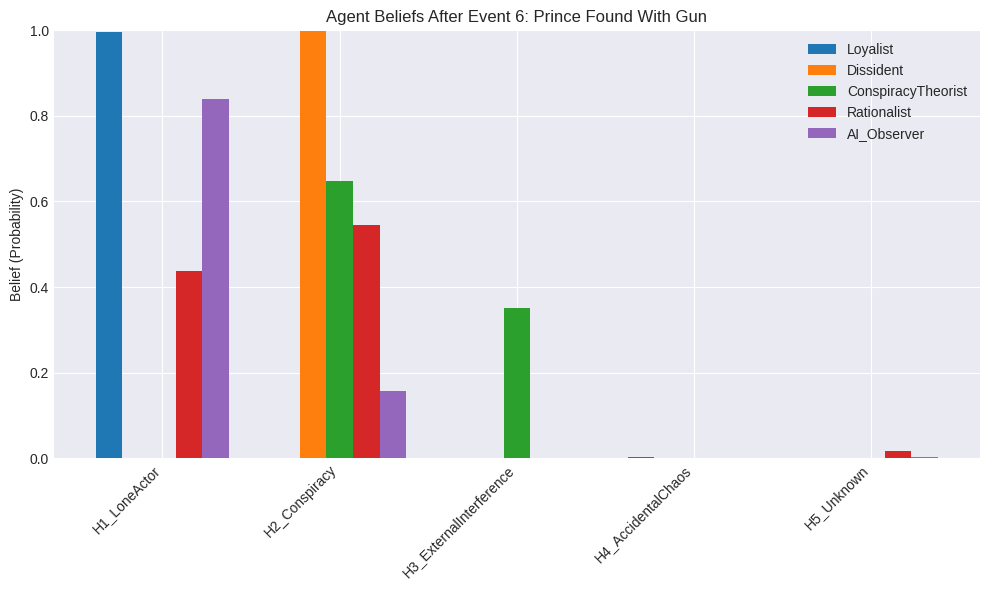

Thoughts Loyalist: The story ends here. A troubled prince, a terrible tragedy. There’s no deeper plot.
Thoughts Dissident: Convenient. Too clean. The fall guy collapses at the climax? I don’t buy it.
Thoughts ConspiracyTheorist: Classic deep-state closure: plant a weapon, leak a motive, silence the key figure.
Thoughts Rationalist: This event is consistent with H1 and H2. Without forensic clarity, we maintain epistemic caution.
Thoughts AI_Observer: Matches patterns from prior lone-actor scenarios, but high-profile deaths often include disinformation.


In [ ]:
# ------------------------
# Event 6
# ------------------------

event6_likelihoods = {
    "Loyalist":           np.array([0.85, 0.3, 0.1, 0.05, 0.2]),
    "Dissident":          np.array([0.4, 0.8, 0.3, 0.01, 0.5]),
    "ConspiracyTheorist": np.array([0.1, 0.95, 0.8, 0.01, 0.6]),
    "Rationalist":        np.array([0.6, 0.6, 0.3, 0.05, 0.5]),
    "AI_Observer":        np.array([0.7, 0.65, 0.4, 0.05, 0.4])
}

# Normalize
for agent, lk in event6_likelihoods.items():
    event6_likelihoods[agent] = lk / lk.sum()

post_event6 = {}

for agent, prior in agents.items():
    likelihood = event6_likelihoods[agent]
    posterior = bayesian_update(prior, likelihood)
    post_event6[agent] = posterior

# Save timeline state
belief_history["Event_6"] = {agent: posterior.copy() for agent, posterior in post_event6.items()}

# Update priors for next event
for agent, posterior in post_event6.items():
    agents[agent] = posterior


plot_agent_beliefs(post_event6, hypotheses, title="Agent Beliefs After Event 6: Prince Found With Gun")

agent_blurbs_event6 = {
    "Loyalist": "The story ends here. A troubled prince, a terrible tragedy. There’s no deeper plot.",
    "Dissident": "Convenient. Too clean. The fall guy collapses at the climax? I don’t buy it.",
    "ConspiracyTheorist": "Classic deep-state closure: plant a weapon, leak a motive, silence the key figure.",
    "Rationalist": "This event is consistent with H1 and H2. Without forensic clarity, we maintain epistemic caution.",
    "AI_Observer": "Matches patterns from prior lone-actor scenarios, but high-profile deaths often include disinformation."
}

# Print interpretations
for agent, blurb in agent_blurbs_event6.items():
    print(f"Thoughts {agent}: {blurb}")


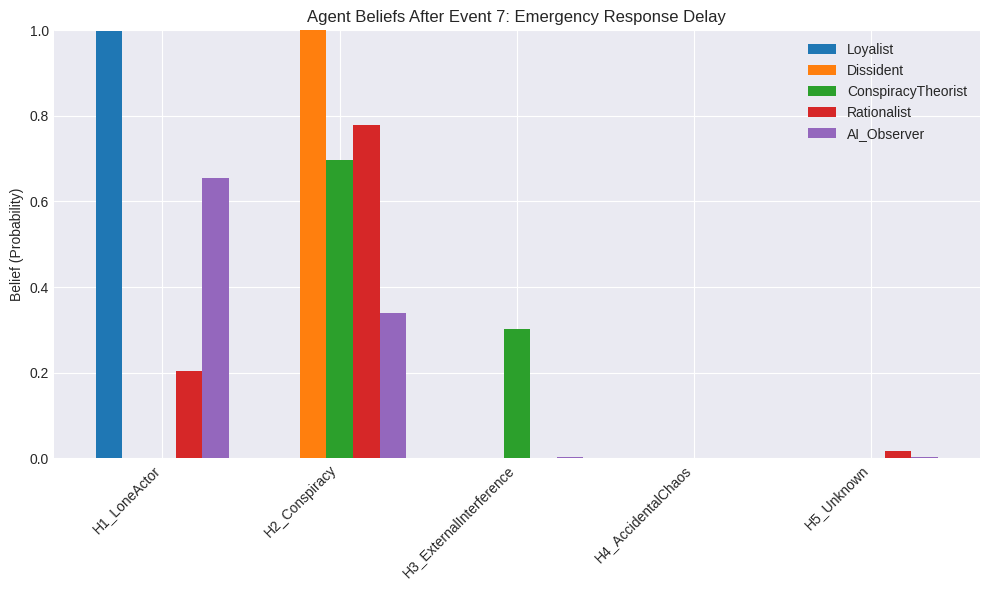

Thoughts Loyalist: In a crisis, wires get crossed. It doesn’t mean someone planned it.
Thoughts Dissident: First the cameras, now the response? This was allowed to happen. Maybe even orchestrated.
Thoughts ConspiracyTheorist: They wanted time to clean up. Delay the responders, control the story. Textbook op.
Thoughts Rationalist: Delay reduces confidence in lone actor theory. H2 and H3 gain substantial posterior mass.
Thoughts AI_Observer: Patterns in past coup or assassination attempts often involve institutional breakdown. Increased weight on H2.


In [ ]:
# ------------------------
# Event 7
# ------------------------

event7_likelihoods = {
    "Loyalist":           np.array([0.3, 0.4, 0.3, 0.2, 0.4]),
    "Dissident":          np.array([0.2, 0.9, 0.5, 0.05, 0.6]),
    "ConspiracyTheorist": np.array([0.05, 0.95, 0.85, 0.01, 0.7]),
    "Rationalist":        np.array([0.4, 0.7, 0.5, 0.1, 0.6]),
    "AI_Observer":        np.array([0.45, 0.75, 0.55, 0.1, 0.5])
}

# Normalize
for agent, lk in event7_likelihoods.items():
    event7_likelihoods[agent] = lk / lk.sum()

post_event7 = {}

for agent, prior in agents.items():
    likelihood = event7_likelihoods[agent]
    posterior = bayesian_update(prior, likelihood)
    post_event7[agent] = posterior

# Save timeline state
belief_history["Event_7"] = {agent: posterior.copy() for agent, posterior in post_event7.items()}

# Update priors for next event
for agent, posterior in post_event7.items():
    agents[agent] = posterior


plot_agent_beliefs(post_event7, hypotheses, title="Agent Beliefs After Event 7: Emergency Response Delay")

agent_blurbs_event7 = {
    "Loyalist": "In a crisis, wires get crossed. It doesn’t mean someone planned it.",
    "Dissident": "First the cameras, now the response? This was allowed to happen. Maybe even orchestrated.",
    "ConspiracyTheorist": "They wanted time to clean up. Delay the responders, control the story. Textbook op.",
    "Rationalist": "Delay reduces confidence in lone actor theory. H2 and H3 gain substantial posterior mass.",
    "AI_Observer": "Patterns in past coup or assassination attempts often involve institutional breakdown. Increased weight on H2."
}

# Print interpretations
for agent, blurb in agent_blurbs_event7.items():
    print(f"Thoughts {agent}: {blurb}")


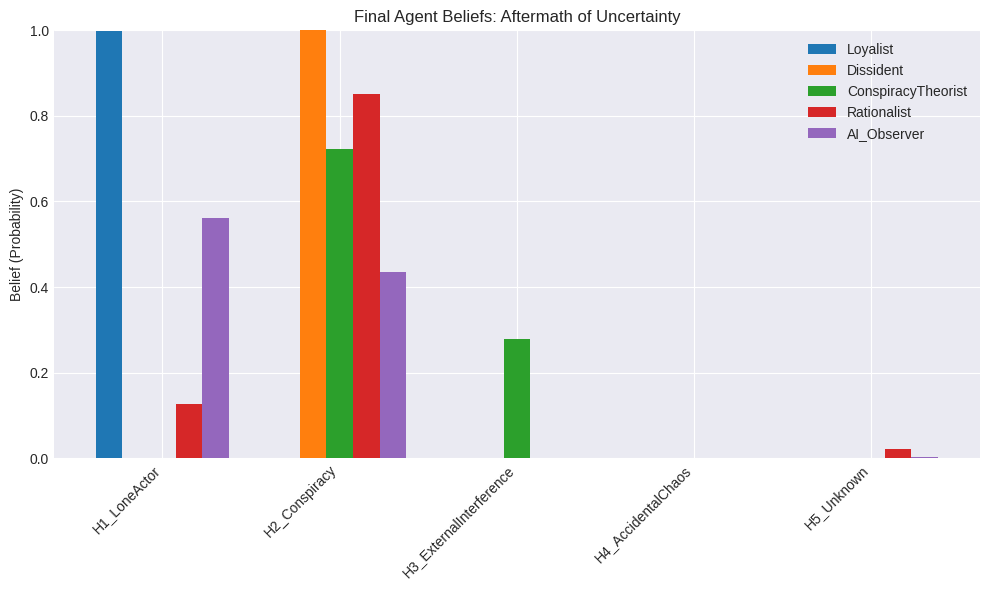

Thoughts Loyalist: Even with confusion, I believe the initial account. We should honor the victims and move forward.
Thoughts Dissident: They can’t even get their story straight. This was a palace job. We’re living in the cover-up.
Thoughts ConspiracyTheorist: Everyone’s lying. The truth was buried with the gun. All stories now are noise and misdirection.
Thoughts Rationalist: The divergence of accounts undermines singular narratives. Posterior distribution remains split, with increasing uncertainty.
Thoughts AI_Observer: Post-conflict environments show instability in reporting. Disinformation likely. H5 gains weight.


In [ ]:
# ------------------------
# Event 8
# ------------------------

event8_likelihoods = {
    "Loyalist":           np.array([0.5, 0.3, 0.2, 0.05, 0.5]),
    "Dissident":          np.array([0.2, 0.95, 0.4, 0.01, 0.7]),
    "ConspiracyTheorist": np.array([0.05, 0.9, 0.8, 0.01, 0.9]),
    "Rationalist":        np.array([0.4, 0.7, 0.3, 0.05, 0.8]),
    "AI_Observer":        np.array([0.5, 0.75, 0.4, 0.05, 0.7])
}

# Normalize
for agent, lk in event8_likelihoods.items():
    event8_likelihoods[agent] = lk / lk.sum()

post_event8 = {}

for agent, prior in agents.items():
    likelihood = event8_likelihoods[agent]
    posterior = bayesian_update(prior, likelihood)
    post_event8[agent] = posterior

# Save timeline state
belief_history["Event_8"] = {agent: posterior.copy() for agent, posterior in post_event8.items()}

# Final beliefs stored
final_beliefs = post_event8

plot_agent_beliefs(final_beliefs, hypotheses, title="Final Agent Beliefs: Aftermath of Uncertainty")

agent_blurbs_event8 = {
    "Loyalist": "Even with confusion, I believe the initial account. We should honor the victims and move forward.",
    "Dissident": "They can’t even get their story straight. This was a palace job. We’re living in the cover-up.",
    "ConspiracyTheorist": "Everyone’s lying. The truth was buried with the gun. All stories now are noise and misdirection.",
    "Rationalist": "The divergence of accounts undermines singular narratives. Posterior distribution remains split, with increasing uncertainty.",
    "AI_Observer": "Post-conflict environments show instability in reporting. Disinformation likely. H5 gains weight."
}

# Print interpretations
for agent, blurb in agent_blurbs_event8.items():
    print(f"Thoughts {agent}: {blurb}")


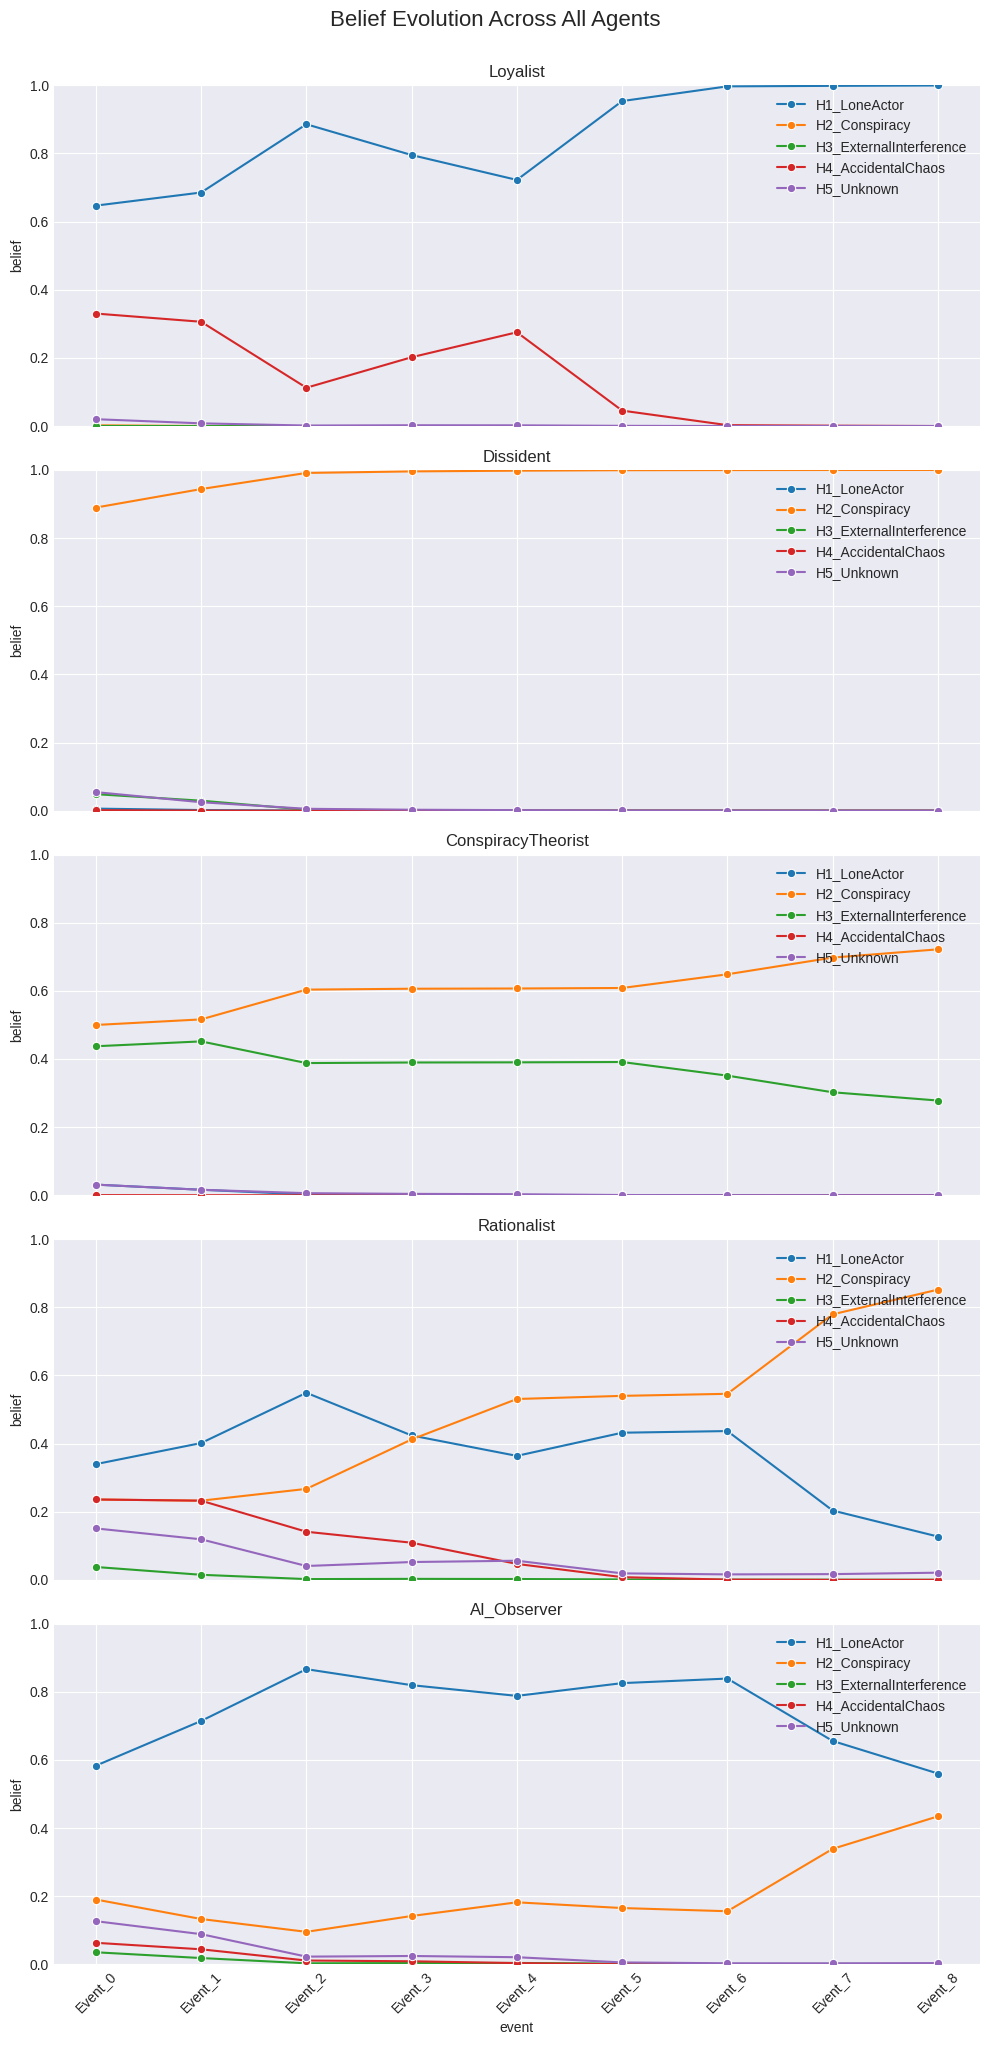

In [ ]:
# Convert belief history to long-form DataFrame
belief_records = []

for event_key, agent_posteriors in belief_history.items():
    for agent, posterior in agent_posteriors.items():
        for i, belief in enumerate(posterior):
            belief_records.append({
                "event": event_key,
                "agent": agent,
                "hypothesis": hypotheses[i],
                "belief": belief
            })

belief_df = pd.DataFrame(belief_records)

import seaborn as sns

def plot_belief_trajectories(df, agent_name=None, figsize=(10,6)):
    """
    Plots belief evolution over time for a specific agent.
    If agent_name is None, shows all agents in subplots.
    """
    if agent_name:
        data = df[df["agent"] == agent_name]
        plt.figure(figsize=figsize)
        sns.lineplot(data=data, x="event", y="belief", hue="hypothesis", marker="o")
        plt.title(f"Belief Evolution – {agent_name}")
        plt.ylim(0, 1)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        agents = df["agent"].unique()
        n_agents = len(agents)
        fig, axes = plt.subplots(n_agents, 1, figsize=(10, 4*n_agents), sharex=True)
        for i, agent in enumerate(agents):
            ax = axes[i]
            data = df[df["agent"] == agent]
            sns.lineplot(data=data, x="event", y="belief", hue="hypothesis", marker="o", ax=ax)
            ax.set_title(f"{agent}")
            ax.set_ylim(0, 1)
            ax.legend(loc='upper right')
            ax.grid(True)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.suptitle("Belief Evolution Across All Agents", y=1.02, fontsize=16)
        plt.show()

plot_belief_trajectories(belief_df)
